In [1]:
import os
import gc
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

physical_gpus = tf.config.list_physical_devices("GPU")

for gpu in physical_gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

strategy = tf.distribute.MirroredStrategy()

print("TensorFlow version:", tf.__version__)
print("Physical GPUs:", physical_gpus)
print("GPUs in use:", strategy.num_replicas_in_sync)

print("\nExperiment: Pixel-Level SMOTE")
print("Image representation: 64×64 grayscale pixels")
print("Features per image: 4096")
print("SMOTE k-neighbors: 5")
print("Class weights: Disabled")
print("Focal loss: Disabled")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.20.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPUs in use: 2

Experiment: Pixel-Level SMOTE
Image representation: 64×64 grayscale pixels
Features per image: 4096
SMOTE k-neighbors: 5
Class weights: Disabled
Focal loss: Disabled


I0000 00:00:1789449932.780406      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789449932.783246      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
dataset_path = kagglehub.dataset_download(
    "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
)

image_root = Path(dataset_path) / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_mapping.items():
    class_folder = image_root / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
from tqdm.auto import tqdm

PIXEL_IMAGE_SIZE = (64, 64)
PIXEL_FEATURES = 64 * 64

def extract_pixel_features(dataframe, description):
    features = np.empty(
        (len(dataframe), PIXEL_FEATURES),
        dtype=np.float32
    )

    for index, filepath in enumerate(
        tqdm(dataframe["filepath"], desc=description)
    ):
        image = cv2.imread(
            filepath,
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.resize(
            image,
            PIXEL_IMAGE_SIZE,
            interpolation=cv2.INTER_AREA
        )

        image = image.astype(np.float32) / 255.0
        features[index] = image.reshape(-1)

    return features

train_pixels = extract_pixel_features(
    train_df,
    "Training images"
)

validation_pixels = extract_pixel_features(
    validation_df,
    "Validation images"
)

test_pixels = extract_pixel_features(
    test_df,
    "Test images"
)

train_labels = train_df["label"].to_numpy(dtype=np.int32)
validation_labels = validation_df["label"].to_numpy(dtype=np.int32)
test_labels = test_df["label"].to_numpy(dtype=np.int32)

print("Training pixels:", train_pixels.shape)
print("Validation pixels:", validation_pixels.shape)
print("Test pixels:", test_pixels.shape)

print(
    "Pixel range:",
    float(train_pixels.min()),
    "to",
    float(train_pixels.max())
)

print("NaN values:", np.isnan(train_pixels).sum())
print("Infinite values:", np.isinf(train_pixels).sum())

Training images:   0%|          | 0/30800 [00:00<?, ?it/s]

Validation images:   0%|          | 0/6600 [00:00<?, ?it/s]

Test images:   0%|          | 0/6600 [00:00<?, ?it/s]

Training pixels: (30800, 4096)
Validation pixels: (6600, 4096)
Test pixels: (6600, 4096)
Pixel range: 0.0 to 1.0
NaN values: 0
Infinite values: 0


In [7]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", Counter(train_labels))

pixel_smote = SMOTE(
    sampling_strategy="auto",
    random_state=SEED,
    k_neighbors=5
)

smote_train_pixels, smote_train_labels = (
    pixel_smote.fit_resample(
        train_pixels,
        train_labels
    )
)

smote_train_pixels = smote_train_pixels.astype(
    np.float32
)
smote_train_labels = smote_train_labels.astype(
    np.int32
)

original_training_count = len(train_pixels)
synthetic_count = (
    len(smote_train_pixels) -
    original_training_count
)

print("After SMOTE:", Counter(smote_train_labels))
print("Original training images:", original_training_count)
print("Synthetic pixel images:", synthetic_count)
print("Final training samples:", len(smote_train_pixels))
print("Final shape:", smote_train_pixels.shape)

print("NaN values:", np.isnan(smote_train_pixels).sum())
print("Infinite values:", np.isinf(smote_train_pixels).sum())
print(
    "Pixel range:",
    float(smote_train_pixels.min()),
    "to",
    float(smote_train_pixels.max())
)

Before SMOTE: Counter({np.int32(1): 21840, np.int32(0): 8960})
After SMOTE: Counter({np.int32(1): 21840, np.int32(0): 21840})
Original training images: 30800
Synthetic pixel images: 12880
Final training samples: 43680
Final shape: (43680, 4096)
NaN values: 0
Infinite values: 0
Pixel range: 0.0 to 1.0


Synthetic image shape: (12880, 64, 64)
Synthetic labels: Counter({np.int32(0): 12880})
Synthetic pixel range: 0.0 to 1.0


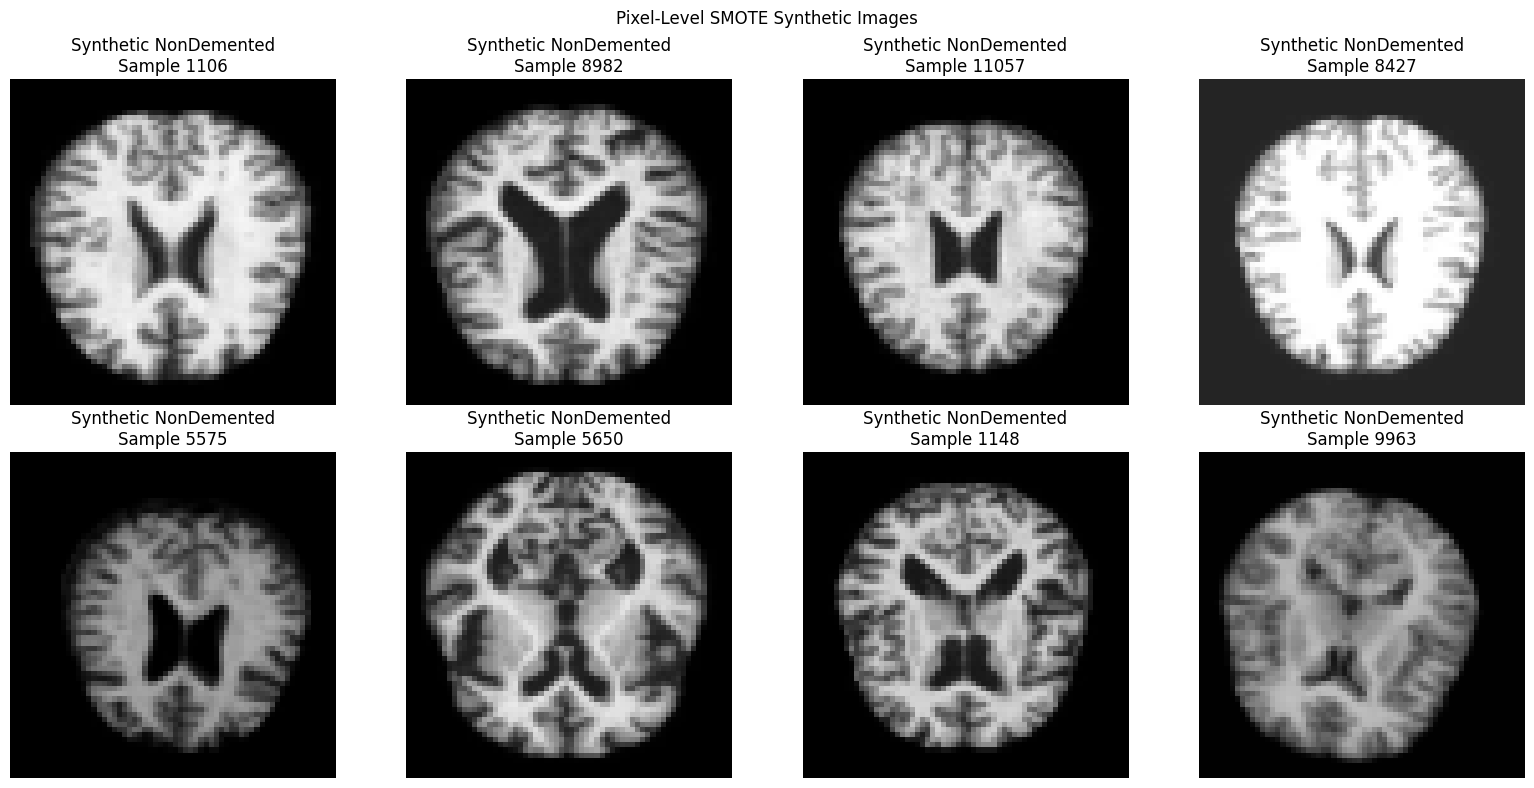

Synthetic pixel-image sanity check passed.


In [8]:
synthetic_pixels = smote_train_pixels[
    original_training_count:
]

synthetic_labels = smote_train_labels[
    original_training_count:
]

synthetic_images = synthetic_pixels.reshape(
    -1,
    PIXEL_IMAGE_SIZE[1],
    PIXEL_IMAGE_SIZE[0]
)

print("Synthetic image shape:", synthetic_images.shape)
print("Synthetic labels:", Counter(synthetic_labels))
print(
    "Synthetic pixel range:",
    float(synthetic_images.min()),
    "to",
    float(synthetic_images.max())
)

assert synthetic_images.shape == (12880, 64, 64)
assert np.all(synthetic_labels == 0)
assert np.isfinite(synthetic_images).all()

rng = np.random.default_rng(SEED)

sample_indices = rng.choice(
    len(synthetic_images),
    size=8,
    replace=False
)

plt.figure(figsize=(16, 8))

for plot_number, index in enumerate(
    sample_indices,
    start=1
):
    plt.subplot(2, 4, plot_number)
    plt.imshow(
        synthetic_images[index],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    plt.title(
        f"Synthetic NonDemented\nSample {index}"
    )
    plt.axis("off")

plt.suptitle("Pixel-Level SMOTE Synthetic Images")
plt.tight_layout()
plt.show()

print("Synthetic pixel-image sanity check passed.")

In [9]:
CLASSIFIER_BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_pixel_dataset = tf.data.Dataset.from_tensor_slices((
    smote_train_pixels,
    smote_train_labels.astype(np.float32)
))

train_pixel_dataset = train_pixel_dataset.shuffle(
    buffer_size=len(smote_train_labels),
    seed=SEED,
    reshuffle_each_iteration=True
).batch(
    CLASSIFIER_BATCH_SIZE
).prefetch(AUTOTUNE)

validation_pixel_dataset = tf.data.Dataset.from_tensor_slices((
    validation_pixels,
    validation_labels.astype(np.float32)
)).batch(
    CLASSIFIER_BATCH_SIZE
).prefetch(AUTOTUNE)

test_pixel_dataset = tf.data.Dataset.from_tensor_slices((
    test_pixels,
    test_labels.astype(np.float32)
)).batch(
    CLASSIFIER_BATCH_SIZE
).prefetch(AUTOTUNE)

pixel_batch, pixel_label_batch = next(
    iter(train_pixel_dataset)
)

print("Pixel batch shape:", pixel_batch.shape)
print("Label batch shape:", pixel_label_batch.shape)

print(
    "NonDemented in first batch:",
    int(tf.reduce_sum(
        tf.cast(pixel_label_batch == 0, tf.int32)
    ))
)

print(
    "Demented in first batch:",
    int(tf.reduce_sum(
        tf.cast(pixel_label_batch == 1, tf.int32)
    ))
)

print("Training batches:", len(train_pixel_dataset))
print("Validation batches:", len(validation_pixel_dataset))
print("Test batches:", len(test_pixel_dataset))

Pixel batch shape: (32, 4096)
Label batch shape: (32,)
NonDemented in first batch: 16
Demented in first batch: 16
Training batches: 1365
Validation batches: 207
Test batches: 207


In [10]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

print("Input pixel features:", PIXEL_FEATURES)
print("Classifier batch size:", CLASSIFIER_BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)

print("Image representation: 64×64 grayscale")
print("Training samples after SMOTE:", len(smote_train_pixels))
print("Loss function: Binary Cross-Entropy")
print("Activation function: Sigmoid")
print("Pixel-level SMOTE: Enabled")
print("Dropout: Disabled")
print("Focal loss: Disabled")
print("Class weights: Disabled")
print("GPUs available:", strategy.num_replicas_in_sync)

Input pixel features: 4096
Classifier batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Image representation: 64×64 grayscale
Training samples after SMOTE: 43680
Loss function: Binary Cross-Entropy
Activation function: Sigmoid
Pixel-level SMOTE: Enabled
Dropout: Disabled
Focal loss: Disabled
Class weights: Disabled
GPUs available: 2


In [11]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

with strategy.scope():
    classifier_inputs = tf.keras.Input(
        shape=(PIXEL_FEATURES,),
        name="flattened_pixels"
    )

    classifier_outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="binary_classifier"
    )(classifier_inputs)

    pixel_classifier = tf.keras.Model(
        classifier_inputs,
        classifier_outputs,
        name="Pixel_SMOTE_Classifier"
    )

    pixel_classifier.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

print("GPUs in use:", strategy.num_replicas_in_sync)
print("Total parameters:", pixel_classifier.count_params())
print("Trainable parameters:", pixel_classifier.count_params())

pixel_classifier.summary()

GPUs in use: 2
Total parameters: 4097
Trainable parameters: 4097


Model: "Pixel_SMOTE_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flattened_pixels (InputLayer)   │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_classifier (Dense)       │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/pixel_level_smote_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks created.")

Callbacks created.


In [13]:
history = pixel_classifier.fit(
    train_pixel_dataset,
    validation_data=validation_pixel_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

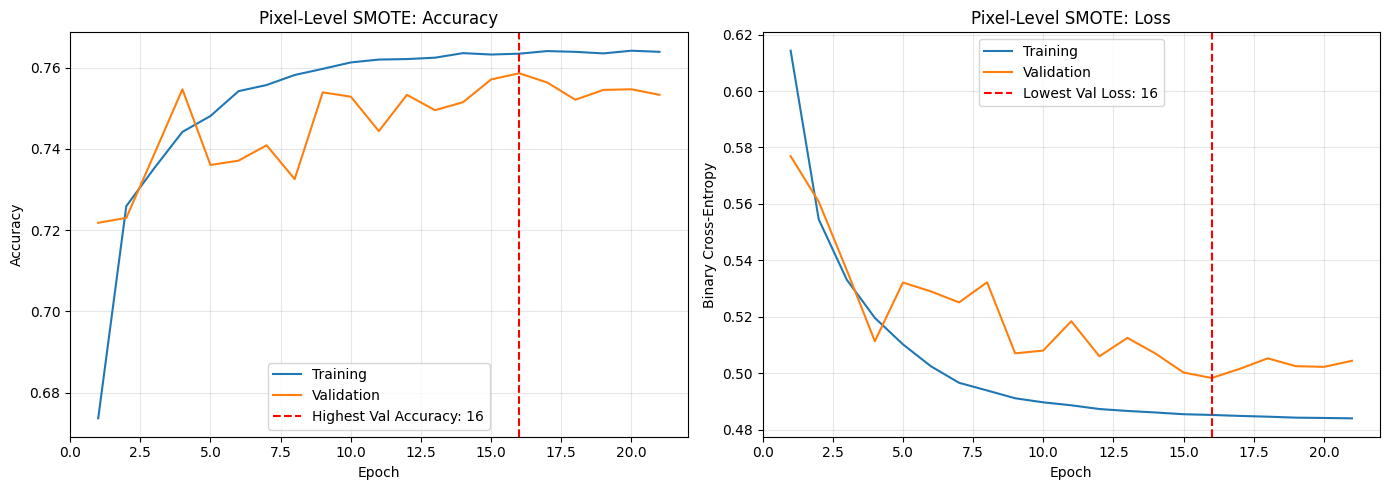

Best validation-loss epoch: 16
Best validation-accuracy epoch: 16
Best validation loss: 0.4984
Highest validation accuracy: 0.7586


In [14]:
best_loss_epoch = np.argmin(
    history.history["val_loss"]
) + 1

best_accuracy_epoch = np.argmax(
    history.history["val_accuracy"]
) + 1

epochs = range(
    1,
    len(history.history["loss"]) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    epochs,
    history.history["accuracy"],
    label="Training"
)
axes[0].plot(
    epochs,
    history.history["val_accuracy"],
    label="Validation"
)
axes[0].axvline(
    best_accuracy_epoch,
    color="red",
    linestyle="--",
    label=f"Highest Val Accuracy: {best_accuracy_epoch}"
)
axes[0].set_title("Pixel-Level SMOTE: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs,
    history.history["loss"],
    label="Training"
)
axes[1].plot(
    epochs,
    history.history["val_loss"],
    label="Validation"
)
axes[1].axvline(
    best_loss_epoch,
    color="red",
    linestyle="--",
    label=f"Lowest Val Loss: {best_loss_epoch}"
)
axes[1].set_title("Pixel-Level SMOTE: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best validation-loss epoch:", best_loss_epoch)
print("Best validation-accuracy epoch:", best_accuracy_epoch)
print(
    "Best validation loss:",
    round(min(history.history["val_loss"]), 4)
)
print(
    "Highest validation accuracy:",
    round(max(history.history["val_accuracy"]), 4)
)

In [15]:
with strategy.scope():
    best_pixel_classifier = tf.keras.models.load_model(
        "/kaggle/working/pixel_level_smote_best.keras"
    )

print("Best pixel-level SMOTE classifier loaded.")
print("Selected validation-loss epoch:", best_loss_epoch)

Best pixel-level SMOTE classifier loaded.
Selected validation-loss epoch: 16


In [16]:
test_loss, test_accuracy = best_pixel_classifier.evaluate(
    test_pixel_dataset,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7662 - loss: 0.4975
Test Loss: 0.4975
Test Accuracy: 0.7662


In [17]:
test_probabilities = best_pixel_classifier.predict(
    test_pixel_dataset,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

true_labels = test_labels

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))

print(
    "Probability range:",
    round(float(test_probabilities.min()), 4),
    "to",
    round(float(test_probabilities.max()), 4)
)

print(
    "First probabilities:",
    np.round(test_probabilities[:10], 4)
)
print("First predictions:", test_predictions[:10])

assert len(true_labels) == len(test_predictions)
assert np.all(
    (test_probabilities >= 0) &
    (test_probabilities <= 1)
)

print("Prediction checks passed.")

207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
Probability range: 0.0129 to 0.9814
First probabilities: [0.8791 0.3978 0.8474 0.4237 0.7504 0.8101 0.6918 0.1904 0.8622 0.5526]
First predictions: [1 0 1 0 1 1 1 0 1 1]
Prediction checks passed.


In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(
    true_labels, test_predictions
).ravel()

specificity = tn / (tn + fp)

accuracy = accuracy_score(
    true_labels, test_predictions
)
balanced_accuracy = balanced_accuracy_score(
    true_labels, test_predictions
)
precision = precision_score(
    true_labels, test_predictions
)
recall = recall_score(
    true_labels, test_predictions
)
f1 = f1_score(
    true_labels, test_predictions
)
roc_auc = roc_auc_score(
    true_labels, test_probabilities
)
pr_auc = average_precision_score(
    true_labels, test_probabilities
)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall/Sensitivity:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Test Loss: 0.4975
Accuracy: 0.7662
Balanced Accuracy: 0.7588
Precision: 0.8797
Recall/Sensitivity: 0.7765
Specificity: 0.7411
F1-score: 0.8249
ROC-AUC: 0.8333
PR-AUC: 0.9157


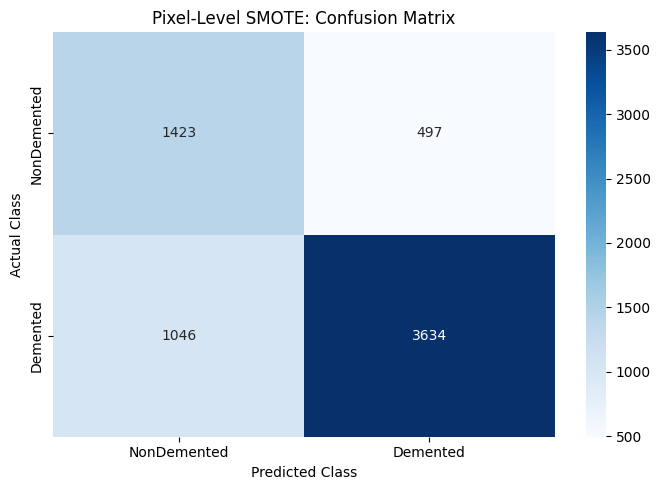

In [19]:
cm = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("Pixel-Level SMOTE: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.5763    0.7411    0.6484      1920
    Demented     0.8797    0.7765    0.8249      4680

    accuracy                         0.7662      6600
   macro avg     0.7280    0.7588    0.7367      6600
weighted avg     0.7914    0.7662    0.7736      6600



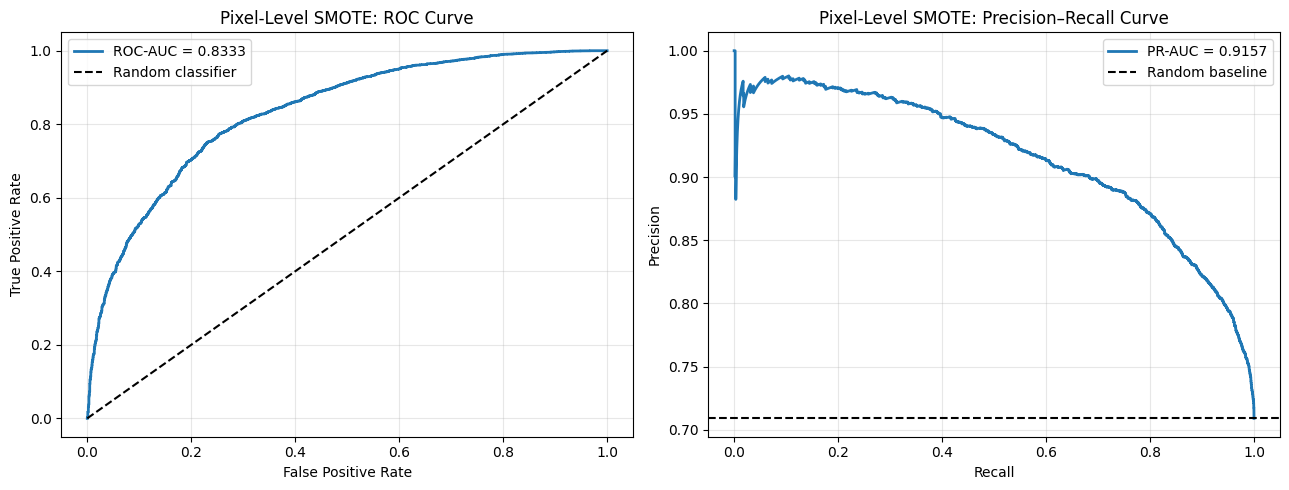

In [21]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(
    true_labels,
    test_probabilities
)

pr_precision, pr_recall, _ = precision_recall_curve(
    true_labels,
    test_probabilities
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}"
)
axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random classifier"
)
axes[0].set_title("Pixel-Level SMOTE: ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)
axes[1].axhline(
    true_labels.mean(),
    color="black",
    linestyle="--",
    label="Random baseline"
)
axes[1].set_title("Pixel-Level SMOTE: Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

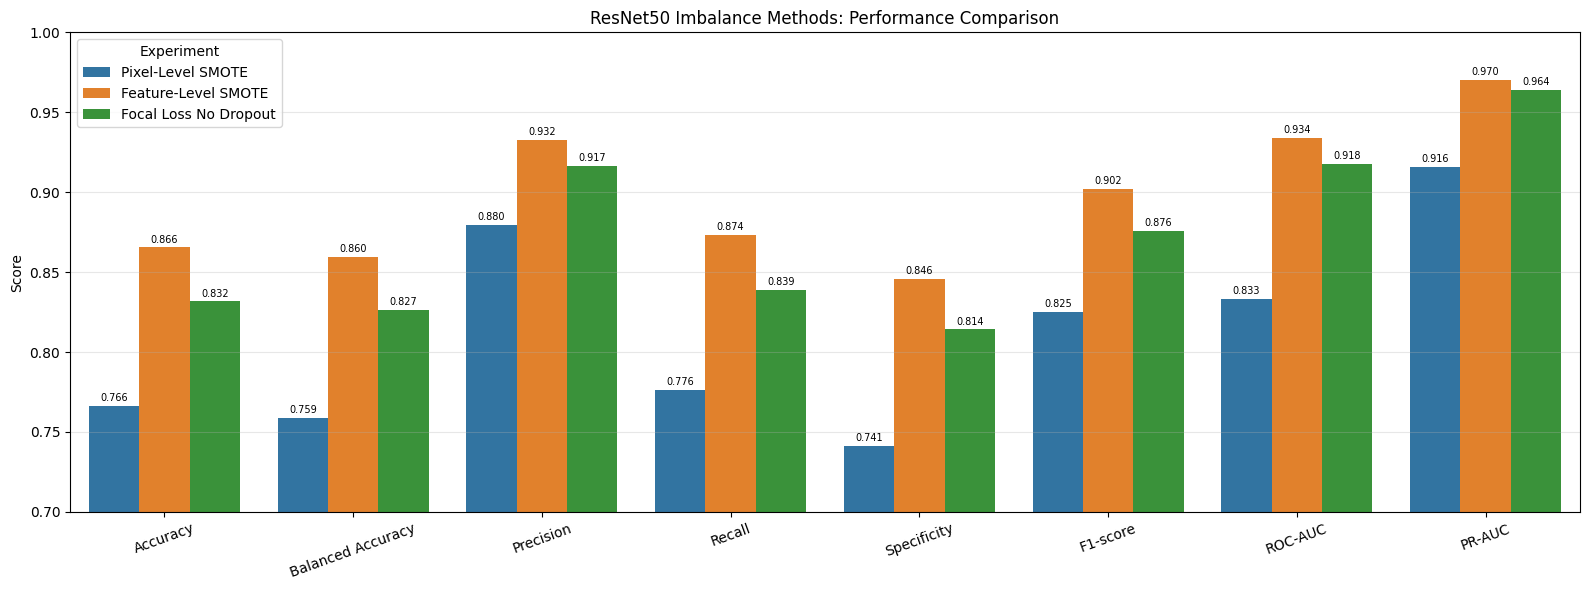

,Metric,Pixel-Level SMOTE,Feature-Level SMOTE,Focal Loss No Dropout
0,Accuracy,0.7662,0.8655,0.8317
1,Balanced Accuracy,0.7588,0.8597,0.8265
2,Precision,0.8797,0.9325,0.9166
3,Recall,0.7765,0.8735,0.8389
4,Specificity,0.7411,0.8458,0.8141
5,F1-score,0.8249,0.9020,0.8760
6,ROC-AUC,0.8333,0.9339,0.9177
7,PR-AUC,0.9157,0.9701,0.9640


In [22]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy", "Balanced Accuracy", "Precision",
        "Recall", "Specificity", "F1-score",
        "ROC-AUC", "PR-AUC"
    ],
    "Pixel-Level SMOTE": [
        0.7662, 0.7588, 0.8797, 0.7765,
        0.7411, 0.8249, 0.8333, 0.9157
    ],
    "Feature-Level SMOTE": [
        0.8655, 0.8597, 0.9325, 0.8735,
        0.8458, 0.9020, 0.9339, 0.9701
    ],
    "Focal Loss No Dropout": [
        0.8317, 0.8265, 0.9166, 0.8389,
        0.8141, 0.8760, 0.9177, 0.9640
    ]
})

plot_data = comparison.melt(
    id_vars="Metric",
    var_name="Experiment",
    value_name="Score"
)

plt.figure(figsize=(16, 6))

ax = sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Experiment"
)

plt.ylim(0.70, 1.0)
plt.title("ResNet50 Imbalance Methods: Performance Comparison")
plt.xlabel("")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=7)

plt.tight_layout()
plt.show()

display(comparison.round(4))

Maximum difference from cached predictions: 1.1920929e-07
End-to-end consistency check passed.


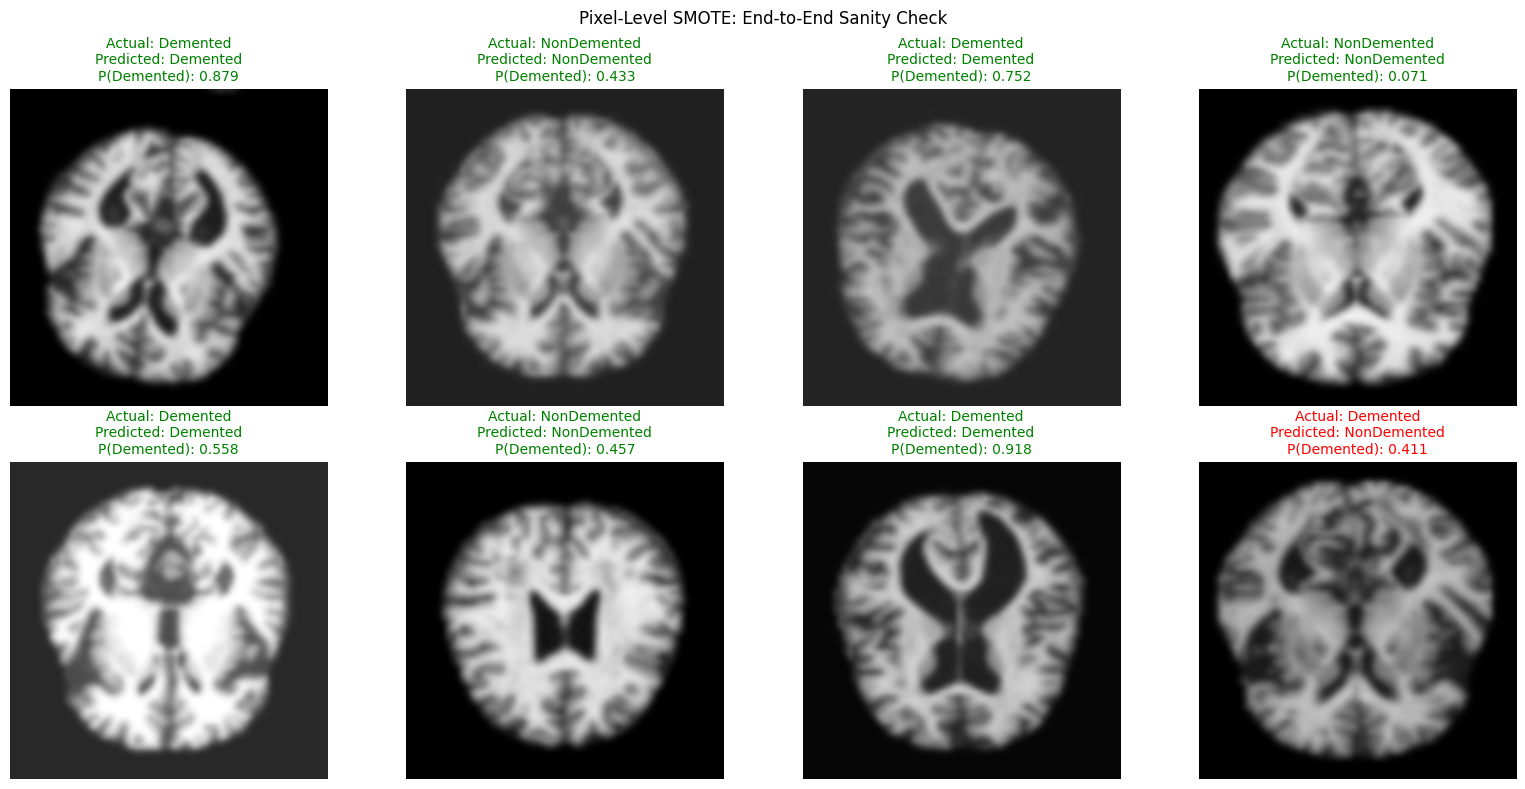

In [30]:
sample_indices = np.linspace(
    0,
    len(test_df) - 1,
    8,
    dtype=int
)

sample_pixel_vectors = []
sample_display_images = []

for index in sample_indices:
    image = cv2.imread(
        test_df.iloc[index]["filepath"],
        cv2.IMREAD_GRAYSCALE
    )

    image = cv2.resize(
        image,
        PIXEL_IMAGE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    normalized_image = (
        image.astype(np.float32) / 255.0
    )

    sample_display_images.append(normalized_image)
    sample_pixel_vectors.append(
        normalized_image.reshape(-1)
    )

sample_pixel_vectors = np.asarray(
    sample_pixel_vectors,
    dtype=np.float32
)

sample_probabilities = best_pixel_classifier.predict(
    sample_pixel_vectors,
    verbose=0
).ravel()

sample_predictions = (
    sample_probabilities >= 0.5
).astype(int)

maximum_difference = np.max(
    np.abs(
        sample_probabilities -
        test_probabilities[sample_indices]
    )
)

print(
    "Maximum difference from cached predictions:",
    maximum_difference
)

assert maximum_difference < 1e-4
print("End-to-end consistency check passed.")

plt.figure(figsize=(16, 8))

for plot_number, index in enumerate(
    sample_indices,
    start=1
):
    actual_name = (
        "Demented" if true_labels[index] == 1
        else "NonDemented"
    )

    predicted_name = (
        "Demented"
        if sample_predictions[plot_number - 1] == 1
        else "NonDemented"
    )

    title_color = (
        "green"
        if true_labels[index] ==
        sample_predictions[plot_number - 1]
        else "red"
    )

    plt.subplot(2, 4, plot_number)
    plt.imshow(
        sample_display_images[plot_number - 1],
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="bicubic"
    )
    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}\n"
        f"P(Demented): "
        f"{sample_probabilities[plot_number - 1]:.3f}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle("Pixel-Level SMOTE: End-to-End Sanity Check")
plt.tight_layout()
plt.show()

In [31]:
import json

results = pd.DataFrame([{
    "Experiment": "Pixel-Level SMOTE",
    "Image Size": "64x64",
    "Pixel Features": PIXEL_FEATURES,
    "SMOTE k-neighbors": 5,
    "Synthetic Samples": synthetic_count,
    "Test Loss": test_loss,
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

results.to_csv(
    "/kaggle/working/pixel_level_smote_results.csv",
    index=False
)

pd.DataFrame(history.history).to_csv(
    "/kaggle/working/pixel_level_smote_history.csv",
    index=False
)

prediction_results = test_df.copy()
prediction_results["probability"] = test_probabilities
prediction_results["prediction"] = test_predictions

prediction_results.to_csv(
    "/kaggle/working/pixel_level_smote_predictions.csv",
    index=False
)

comparison.to_csv(
    "/kaggle/working/pixel_vs_feature_smote_comparison.csv",
    index=False
)

experiment_config = {
    "seed": SEED,
    "image_size": list(PIXEL_IMAGE_SIZE),
    "grayscale": True,
    "normalization": "divide_by_255",
    "flattened_features": PIXEL_FEATURES,
    "smote_k_neighbors": 5,
    "smote_sampling_strategy": "auto",
    "loss": "binary_crossentropy",
    "activation": "sigmoid",
    "threshold": 0.5,
    "dropout": False,
    "focal_loss": False,
    "class_weights": False
}

with open(
    "/kaggle/working/pixel_level_smote_config.json",
    "w"
) as file:
    json.dump(experiment_config, file, indent=4)

display(results)
print("All pixel-level SMOTE files saved.")

,Experiment,Image Size,Pixel Features,SMOTE k-neighbors,Synthetic Samples,Test Loss,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,Pixel-Level SMOTE,64x64,4096,5,12880,0.497528,0.766212,0.758821,0.87969,0.776496,0.741146,0.824878,0.833277,0.915668


All pixel-level SMOTE files saved.
